<a href="https://colab.research.google.com/github/tungduong2106/Linear-Regression/blob/main/Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/Colab Notebooks/data


/content/drive/MyDrive/Colab Notebooks/data


In [ ]:
!pip install pyvi

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from pyvi import ViTokenizer

import sklearn.naive_bayes as nb
from sklearn.datasets import load_files
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import ShuffleSplit, learning_curve

%matplotlib inline

In [ ]:
data_train = load_files(container_path="/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)", encoding="utf-8")

print(data_train.filenames[0:3])
print()
print("Tong so file: {}" .format(len(data_train.filenames)))
print("Danh sach 10 nhan va id tuong ung: ",[(idx,name) for idx,name in enumerate(data_train.target_names[0:10])])


['/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Pháp luật/0e7537e00a4dd4c8c1b8d786858885c920311800.txt'
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Thời sự (1)/7ea376282b8acc4cb3784dbaa9fa995b52e57ce1.txt'
 '/content/drive/MyDrive/Colab Notebooks/data (1)/news_1135 (1)/Thể thao (1)/e78ef641b159653587e011d5929935b33e78c8d8 (1).txt']

Tong so file: 1027
Danh sach 10 nhan va id tuong ung:  [(0, 'Khoa học - Công nghệ'), (1, 'Kinh tế'), (2, 'Pháp luật'), (3, 'Sức khỏe (1)'), (4, 'Thể thao (1)'), (5, 'Thời sự (1)'), (6, 'Tin kh†c'), (7, 'Đời sống - Xã hội'), (8, 'Độc giả')]


In [ ]:
# Lấy văn bản đầu tiên
print("Nội dung văn bản đầu tiên:\n")
print(data_train.data[0][:100])   # In 500 ký tự đầu để tránh quá dài
print("Nhãn số:", data_train.target[0])
print("Tên nhãn:", data_train.target_names[data_train.target[0]])


Nội dung văn bản đầu tiên:

Dân_trí Theo trình_báo của một người sống lâu_năm trong chùa , chiều pho tượng Phật trên Chánh điện 
Nhãn số: 2
Tên nhãn: Pháp luật


In [ ]:
with open("/content/drive/MyDrive/Colab Notebooks/data (1)/vietnamese-stopwords (1).txt", encoding="utf-8") as f:
    stopwords = f.readlines()
stopwords = [x.strip().replace(" ","_") for x in stopwords]
print("Danh sach 10 tu dung dau tien: ", stopwords[0:10])
print()

module_count_vector = CountVectorizer(stop_words=stopwords) # loai bo stopwords
module_rf_preprocess = Pipeline([('vect', module_count_vector),('tfidf',TfidfTransformer())]) # Bien van ban thanh ma tran dem tu sau do chuan hoa ma tran
data_bow = module_count_vector.fit_transform(data_train.data, data_train.target)
data_tfidf = module_rf_preprocess.fit_transform(data_train.data, data_train.target)

print("10 tu dau tien trong tu dien: \n")
i=0
for k,v in module_count_vector.vocabulary_.items():
  i+=1
  print(i,": ",(k,v))
  if i > 10 : break
print()

Danh sach 10 tu dung dau tien:  ['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']

10 tu dau tien trong tu dien: 

1 :  ('dân_trí', 6637)
2 :  ('trình_báo', 18949)
3 :  ('sống', 17035)
4 :  ('lâu_năm', 11077)
5 :  ('chùa', 4684)
6 :  ('chiều', 4401)
7 :  ('tượng', 19801)
8 :  ('phật', 14925)
9 :  ('chánh', 4551)
10 :  ('điện', 22142)
11 :  ('nam', 12684)



In [ ]:
test_size = 0.2
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(data_bow, data_train.target, test_size= test_size, random_state=30)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(data_tfidf, data_train.target, test_size= test_size, random_state=30)

print("Du lieu train = ", X_train_bow.shape, X_train_tfidf.shape)
print("Du lieu test = ", X_test_bow.shape, X_test_tfidf.shape)

print()
print("Danh sach nhan va id tuong ung : ", [(idx,name) for idx,name in enumerate(data_train.target_names)])

Du lieu train =  (821, 23343) (821, 23343)
Du lieu test =  (206, 23343) (206, 23343)

Danh sach nhan va id tuong ung :  [(0, 'Khoa học - Công nghệ'), (1, 'Kinh tế'), (2, 'Pháp luật'), (3, 'Sức khỏe (1)'), (4, 'Thể thao (1)'), (5, 'Thời sự (1)'), (6, 'Tin kh†c'), (7, 'Đời sống - Xã hội'), (8, 'Độc giả')]


In [ ]:
for i in range(5):
    label_id = y_train_bow[i]
    label_name = data_train.target_names[label_id]
    print(f"Văn bản {i}: id = {label_id}, nhãn = {label_name}")

Văn bản 0: id = 8, nhãn = Độc giả
Văn bản 1: id = 0, nhãn = Khoa học - Công nghệ
Văn bản 2: id = 3, nhãn = Sức khỏe (1)
Văn bản 3: id = 1, nhãn = Kinh tế
Văn bản 4: id = 1, nhãn = Kinh tế


In [ ]:
print("- Train size = {}" .format(X_train_bow.shape))
model_MNB = nb.MultinomialNB(alpha=0.1)
model_MNB.fit(X_train_bow, y_train_bow)

- Train size = (821, 23343)


MultinomialNB(alpha=0.1)

In [ ]:
print("- Train size = {}" .format(X_train_tfidf.shape))
model_GNB = nb.GaussianNB(var_smoothing=1e-3)
model_GNB.fit(X_train_tfidf.toarray(), y_train_tfidf)

- Train size = (821, 23343)


GaussianNB(var_smoothing=0.001)

X_train_tfidf là một ma trận thưa (sparse matrix) do TfidfTransformer tạo ra.

GaussianNB trong sklearn lại không hỗ trợ trực tiếp sparse matrix, mà chỉ nhận numpy array hoặc dense matrix.

In [ ]:
# Đánh giá MNB
y_pred_MNB = model_MNB.predict(X_test_bow)
print("=== Đánh giá theo từng nhãn (MultinomialNB - BoW) ===")
import pandas as pd
report = classification_report(
    y_test_bow, y_pred_MNB,
    labels=range(len(data_train.target_names)),
    target_names=data_train.target_names,
    output_dict=True
)
df = pd.DataFrame(report).transpose()
print(df)
print("Hamming Loss:", hamming_loss(y_test_bow, y_pred_MNB))
print("Exact Match Accuracy:", accuracy_score(y_test_bow, y_pred_MNB))

=== Đánh giá theo từng nhãn (MultinomialNB - BoW) ===
                          precision    recall  f1-score     support
Khoa học - Công nghệ   0.928571  0.951220  0.939759   41.000000
Kinh tế                  0.857143  0.857143  0.857143   35.000000
Pháp luật               0.714286  0.833333  0.769231   12.000000
Sức khỏe (1)            0.833333  0.882353  0.857143   17.000000
Thể thao (1)             1.000000  0.958333  0.978723   24.000000
Thời sự (1)            0.958333  0.920000  0.938776   25.000000
Tin kh†c                   0.875000  0.913043  0.893617   23.000000
Đời sống - Xã hội   0.941176  0.842105  0.888889   19.000000
Độc giả                 0.888889  0.800000  0.842105   10.000000
accuracy                   0.898058  0.898058  0.898058    0.898058
macro avg                  0.888526  0.884170  0.885043  206.000000
weighted avg               0.901282  0.898058  0.898807  206.000000
Hamming Loss: 0.10194174757281553
Exact Match Accuracy: 0.8980

In [ ]:
# Đánh giá GNB
y_pred_GNB = model_GNB.predict(X_test_tfidf.toarray())
print("\n=== Đánh giá theo từng nhãn (GaussianNB - TF-IDF) ===")
import pandas as pd
report = classification_report(
    y_test_tfidf, y_pred_GNB,
    labels=range(len(data_train.target_names)),
    target_names=data_train.target_names,
    output_dict=True
)
df = pd.DataFrame(report).transpose()
print(df)
print("Hamming Loss:", hamming_loss(y_test_tfidf, y_pred_GNB))
print("Exact Match Accuracy:", accuracy_score(y_test_tfidf, y_pred_GNB))


=== Đánh giá theo từng nhãn (GaussianNB - TF-IDF) ===
                          precision    recall  f1-score     support
Khoa học - Công nghệ   0.866667  0.951220  0.906977   41.000000
Kinh tế                  0.763158  0.828571  0.794521   35.000000
Pháp luật               0.777778  0.583333  0.666667   12.000000
Sức khỏe (1)            0.722222  0.764706  0.742857   17.000000
Thể thao (1)             1.000000  0.916667  0.956522   24.000000
Thời sự (1)            0.846154  0.880000  0.862745   25.000000
Tin kh†c                   0.739130  0.739130  0.739130   23.000000
Đời sống - Xã hội   0.705882  0.631579  0.666667   19.000000
Độc giả                 0.875000  0.700000  0.777778   10.000000
accuracy                   0.815534  0.815534  0.815534    0.815534
macro avg                  0.810666  0.777245  0.790429  206.000000
weighted avg               0.816362  0.815534  0.813555  206.000000
Hamming Loss: 0.18446601941747573
Exact Match Accuracy: 0.815

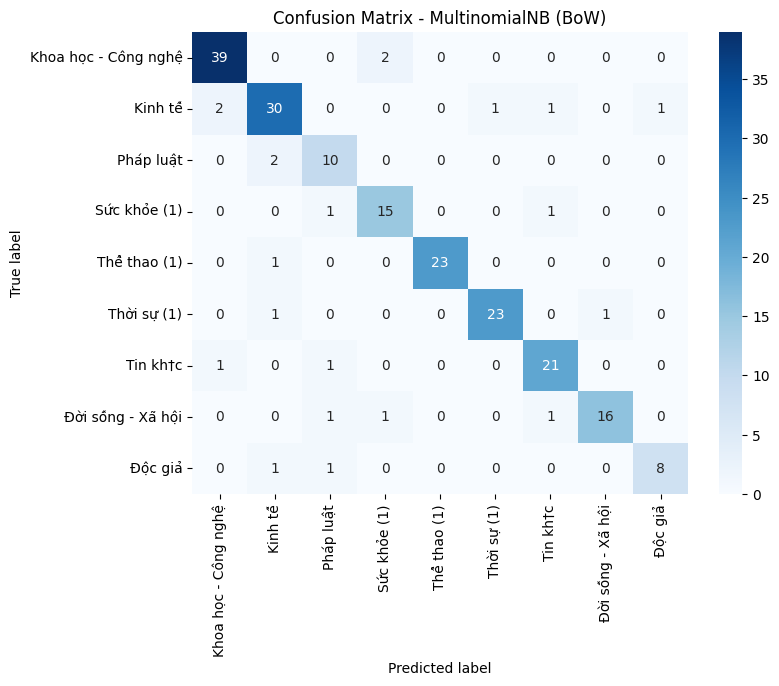

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Confusion Matrix cho MultinomialNB (BoW)
y_pred_MNB = model_MNB.predict(X_test_bow)
cm_MNB = confusion_matrix(y_test_bow, y_pred_MNB, labels=range(len(data_train.target_names)))
plt.figure(figsize=(8,6))
sns.heatmap(cm_MNB, annot=True, fmt="d", cmap="Blues",
            xticklabels=data_train.target_names,
            yticklabels=data_train.target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - MultinomialNB (BoW)")
plt.show()


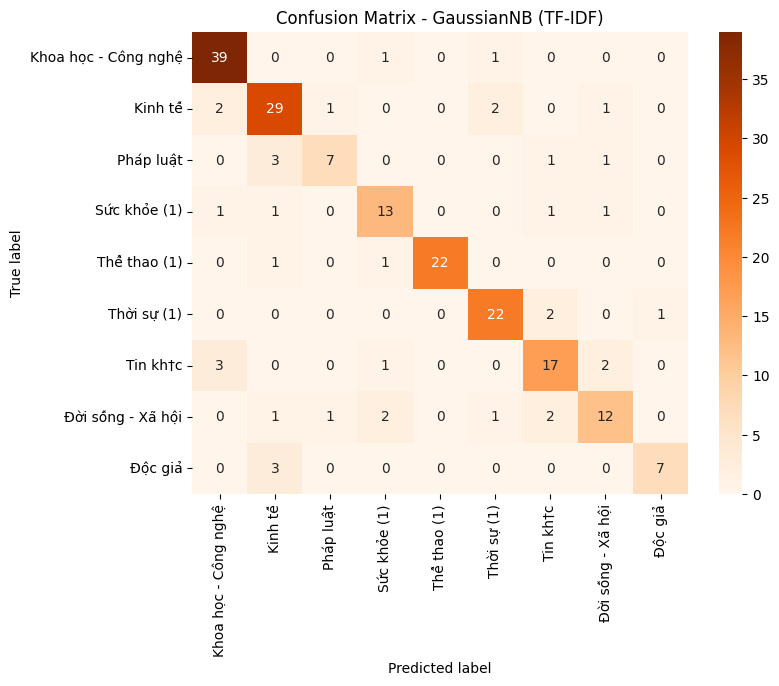

In [ ]:
# Confusion Matrix cho GaussianNB (TF-IDF)
y_pred_GNB = model_GNB.predict(X_test_tfidf.toarray())
cm_GNB = confusion_matrix(y_test_tfidf, y_pred_GNB, labels=range(len(data_train.target_names)))
plt.figure(figsize=(8,6))
sns.heatmap(cm_GNB, annot=True, fmt="d", cmap="Oranges",
            xticklabels=data_train.target_names,
            yticklabels=data_train.target_names)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - GaussianNB (TF-IDF)")
plt.show()

In [ ]:
a = ViTokenizer.tokenize("Tôi là sinh viên Bách Khoa")
print(a)

Tôi là sinh_viên Bách_Khoa


In [ ]:
new_text = ViTokenizer.tokenize("Công phượng ghi bàn cho đội tuyển Việt Nam")
print(new_text)
input_data_preprocessed = module_count_vector.transform([new_text])
print(input_data_preprocessed)

print("Danh sach nhan va id tuong ung : ", [(idx,name) for idx,name in enumerate(data_train.target_names)])

Công phượng ghi_bàn cho đội_tuyển Việt_Nam
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (1, 23343)>
  Coords	Values
  (0, 5604)	1
  (0, 7434)	1
  (0, 14857)	1
  (0, 20576)	1
  (0, 23104)	1
Danh sach nhan va id tuong ung :  [(0, 'Khoa học - Công nghệ'), (1, 'Kinh tế'), (2, 'Pháp luật'), (3, 'Sức khỏe (1)'), (4, 'Thể thao (1)'), (5, 'Thời sự (1)'), (6, 'Tin kh†c'), (7, 'Đời sống - Xã hội'), (8, 'Độc giả')]


In [ ]:
prediction = model_MNB.predict(input_data_preprocessed.toarray())
predicted_label_id = prediction[0]
print("ID nhãn dự đoán: ",predicted_label_id)
target_names = data_train.target_names
print("Tên nhãn dự đoán: ",target_names[predicted_label_id])

ID nhãn dự đoán:  4
Tên nhãn dự đoán:  Thể thao (1)


var_smoothing = 0.1, Acc = 0.7669902912621359
var_smoothing = 0.01, Acc = 0.7912621359223301
var_smoothing = 0.001, Acc = 0.8155339805825242
var_smoothing = 0.0001, Acc = 0.7912621359223301
var_smoothing = 1e-05, Acc = 0.7864077669902912


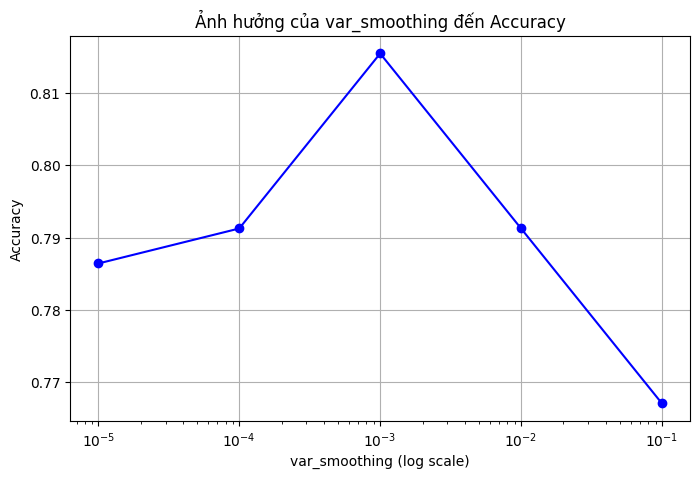

In [ ]:
var_smoothings = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
accs = []
for var_smoothing in var_smoothings:
    model_GNB = nb.GaussianNB(var_smoothing=var_smoothing)
    model_GNB.fit(X_train_tfidf.toarray(), y_train_tfidf)
    y_pred_tfidf = model_GNB.predict(X_test_tfidf.toarray())
    acc = accuracy_score(y_test_tfidf, y_pred_tfidf)
    accs.append(acc)

for i in range(len(accs)):
    print(f"var_smoothing = {var_smoothings[i]}, Acc = {accs[i]}")

plt.figure(figsize=(8, 5))
plt.plot(var_smoothings, accs, marker='o', linestyle='-', color='b')
plt.xscale('log')
plt.xlabel("var_smoothing (log scale)")
plt.ylabel("Accuracy")
plt.title("Ảnh hưởng của var_smoothing đến Accuracy")
plt.grid(True)
plt.show()